In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['target']=iris.target

X = df[iris.feature_names]
y = iris.target
features = iris.feature_names
classes = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8, random_state=13, stratify=y)
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


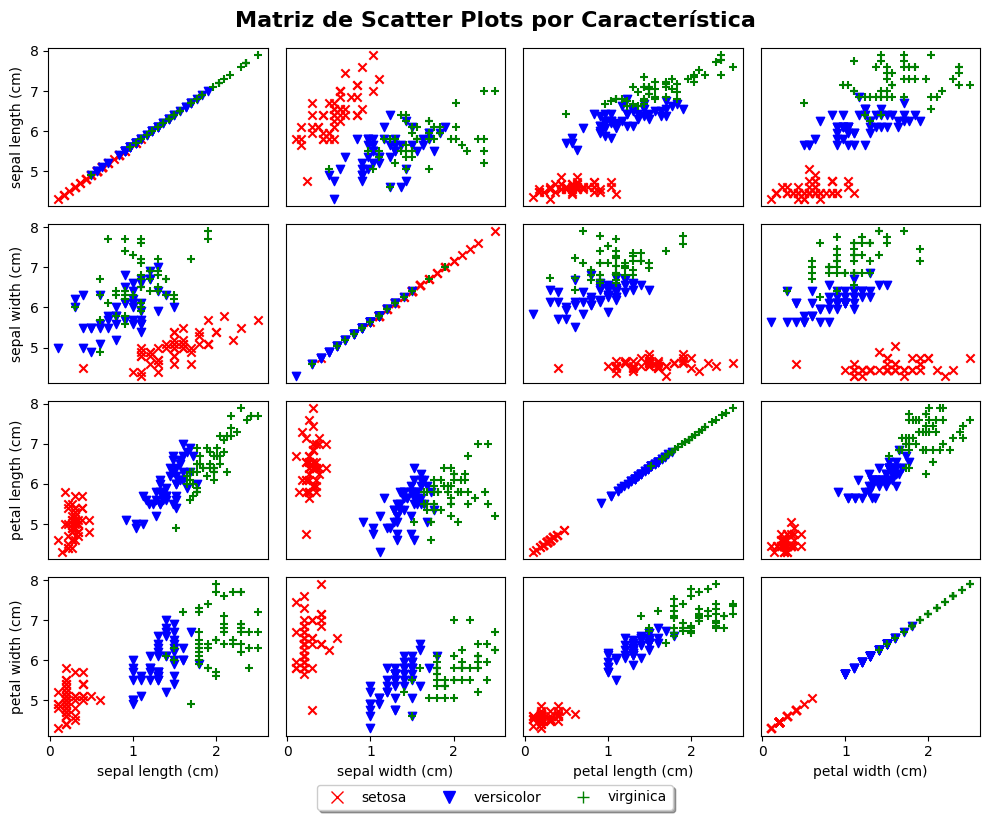

In [3]:
n = len(features)
c = ['red', 'blue', 'green']
fig = plt.figure(figsize=(10, 8))
for i, feature in enumerate(features):
    for j,f in enumerate(features):
        ax = plt.subplot(n,n, i * n + j + 1 )
        plt.scatter(X[feature][:50], X[f][:50], c=c[0], marker="x")
        plt.scatter(X[feature][50:100], X[f][50:100], c=c[1], marker="v")
        plt.scatter(X[feature][100:], X[f][100:], c=c[2], marker="+")
        if j == 0:
            ax.set_ylabel(feature)
        else:
            ax.set_yticks([]) 
        if i == len(features) - 1:
            ax.set_xlabel(f)
        else:
            ax.set_xticks([]) 

legend_elements = [
    plt.Line2D([0], [0], marker='x', color='red', linestyle='', 
               markersize=8, label=classes[0]),
    plt.Line2D([0], [0], marker='v', color='blue', linestyle='', 
               markersize=8, label=classes[1]),
    plt.Line2D([0], [0], marker='+', color='green', linestyle='', 
               markersize=8, label=classes[2])
]

fig.legend(handles=legend_elements, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.02),  
           ncol=3, 
           frameon=True,
           fancybox=True,
           shadow=True)

plt.suptitle('Matriz de Scatter Plots por Característica', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

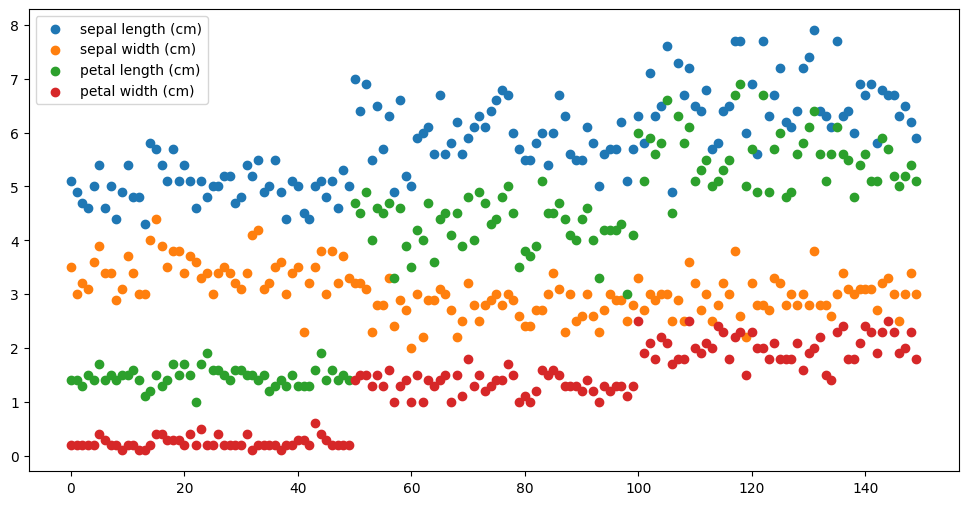

In [4]:
muestras = np.arange(len(X))
fig = plt.figure(figsize=(12,6))
for i, feature in enumerate(features):
    plt.scatter(muestras, X[feature], label=features[i])
    plt.legend()

In [5]:
metrics =["euclidean", "cosine", "manhattan"]
weights = ["uniform", "distance"]
n_neighbors = [1,3,5,7,9]

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_weighted': make_scorer(precision_score, average='weighted'),
    'recall_weighted': make_scorer(recall_score, average='weighted'),
    'f1_weighted': make_scorer(f1_score, average='weighted')
}

parameters = {'metric': metrics,
              'weights': weights,
              'n_neighbors': n_neighbors
              }

def trainingKnnScoring(metric):
    model_tuning = GridSearchCV(
        estimator =KNeighborsClassifier(),
        param_grid = parameters,
        refit=metric,
        scoring=scoring)

    model_tuning.fit(X_train, y_train)

    best_param = model_tuning.best_params_
    best_knn = model_tuning.best_estimator_

    best_result = pd.DataFrame.from_dict(model_tuning.cv_results_)


    y_pred = best_knn.predict(X_test)

    print(f'{metric}={best_knn.score(X_test,y_test)*100:.2f}%')
    print(f"Best parameters: {best_param}")
    return best_result
for score in scoring:
    trainingKnnScoring(score)
    print()

accuracy=96.67%
Best parameters: {'metric': 'cosine', 'n_neighbors': 7, 'weights': 'uniform'}

precision_weighted=96.67%
Best parameters: {'metric': 'cosine', 'n_neighbors': 7, 'weights': 'uniform'}

recall_weighted=96.67%
Best parameters: {'metric': 'cosine', 'n_neighbors': 7, 'weights': 'uniform'}

f1_weighted=96.67%
Best parameters: {'metric': 'cosine', 'n_neighbors': 7, 'weights': 'uniform'}

